# Momentum Strategy Backtest

A vectorized backtest of a cross-sectional momentum strategy: each month, rank a universe of large-cap stocks by trailing 6-month returns, hold the top 3 equal-weighted for the next month, and compare risk-adjusted performance against a buy-and-hold SPY benchmark.

**This notebook is a walkthrough of the methodology.** For the production-style version, see `src/run_analysis.py` and the modules in `src/`.

**Data note:** This repo ships with `data/prices.csv`, which is realistic placeholder data calibrated to historical risk/return profiles (generated by `src/generate_data.py`) because this environment couldn't reach Yahoo Finance. Run `src/fetch_data.py` on a machine with internet access to pull real data and overwrite that file — the rest of the pipeline works unchanged.

In [1]:
import sys
sys.path.append('src')

import pandas as pd
import matplotlib.pyplot as plt

from backtest import run_backtest
from metrics import summary_table

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
%matplotlib inline

## 1. Load price data

In [2]:
prices = pd.read_csv('data/prices.csv', index_col='Date', parse_dates=True).sort_index()
benchmark_prices = prices['SPY']
stock_prices = prices.drop(columns=['SPY'])

print(f"{len(prices)} trading days from {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Universe: {list(stock_prices.columns)}")
prices.head()

1304 trading days from 2020-01-02 to 2024-12-31
Universe: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'JNJ', 'KO', 'XOM']


,SPY,AAPL,MSFT,NVDA,AMZN,GOOGL,JNJ,KO,XOM
Date,,,,,,,,,
2020-01-02,322.9300,73.4900,157.8800,6.1000,93.8500,67.8600,144.7000,55.0000,70.6300
2020-01-03,321.3500,72.5600,158.6500,6.0900,92.9300,68.5900,144.6100,55.3700,71.5900
2020-01-06,323.9600,73.4600,158.4000,6.1800,93.5500,68.6900,143.4000,55.5700,72.0400
2020-01-07,319.0600,73.6600,156.0200,6.2500,93.6700,68.7400,141.3400,55.8100,70.4100
2020-01-08,325.3000,72.9100,154.4500,6.4500,94.6000,68.5600,140.9300,56.1600,71.0800


## 2. Visualize raw price history

Before building any strategy, always look at the raw data. This is also a good sanity check for stock splits, gaps, or bad data points.

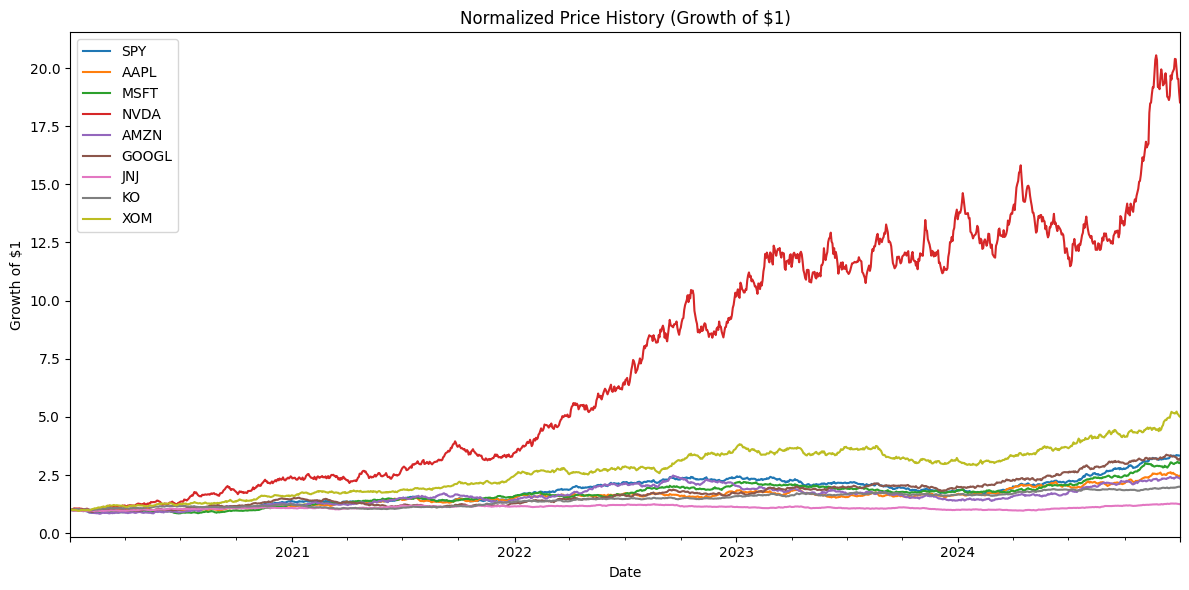

In [3]:
normalized = prices / prices.iloc[0]
ax = normalized.plot(figsize=(12, 6), title='Normalized Price History (Growth of $1)')
ax.set_ylabel('Growth of $1')
plt.tight_layout()
plt.show()

## 3. Run the momentum backtest

Key parameters:
- **Lookback window**: 6 months of trailing returns used to rank stocks.
- **Top K**: hold the top 3 ranked stocks, equal-weighted.
- **Rebalance frequency**: monthly.
- **Transaction cost**: 10 bps charged on portfolio turnover at each rebalance.
- **Skip most recent month**: the signal excludes the most recent 1-month return, following the standard momentum literature (Jegadeesh & Titman, 1993) — very short-term returns tend to reverse rather than continue.

In [4]:
result = run_backtest(
    stock_prices,
    lookback_months=6,
    top_k=3,
    transaction_cost_bps=10.0,
    skip_recent_month=True,
)

strategy_returns = result['daily_returns']
benchmark_returns = benchmark_prices.pct_change().fillna(0).loc[strategy_returns.index]

print(f"Backtest active from {strategy_returns.index[0].date()} to {strategy_returns.index[-1].date()}")
print(f"Number of rebalances: {len(result['holdings_log'])}")

Backtest active from 2020-08-31 to 2024-12-31
Number of rebalances: 52


## 4. Performance metrics

In [5]:
strategy_metrics = summary_table(strategy_returns)
benchmark_metrics = summary_table(benchmark_returns)

comparison = pd.DataFrame({'Momentum Strategy': strategy_metrics, 'SPY Benchmark': benchmark_metrics})
comparison

,Momentum Strategy,SPY Benchmark
Cumulative Return,2.8434,2.1644
CAGR,0.3495,0.2923
Annualized Volatility,0.1469,0.1748
Sharpe Ratio,1.8473,1.3303
Sortino Ratio,3.1691,2.3664
Max Drawdown,-0.1380,-0.3184
Calmar Ratio,2.5321,0.9181
Win Rate,0.5292,0.5424


## 5. Equity curve: strategy vs benchmark

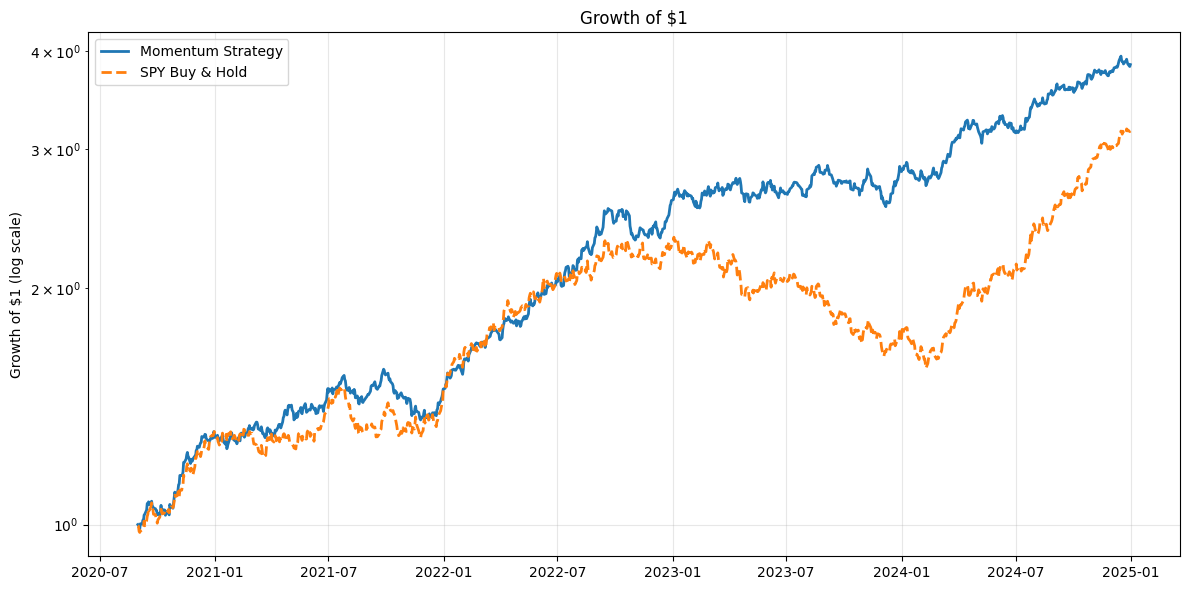

In [6]:
strat_equity = (1 + strategy_returns).cumprod()
bench_equity = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strat_equity, label='Momentum Strategy', linewidth=2)
plt.plot(bench_equity, label='SPY Buy & Hold', linewidth=2, linestyle='--')
plt.yscale('log')
plt.title('Growth of $1')
plt.ylabel('Growth of $1 (log scale)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Drawdown comparison

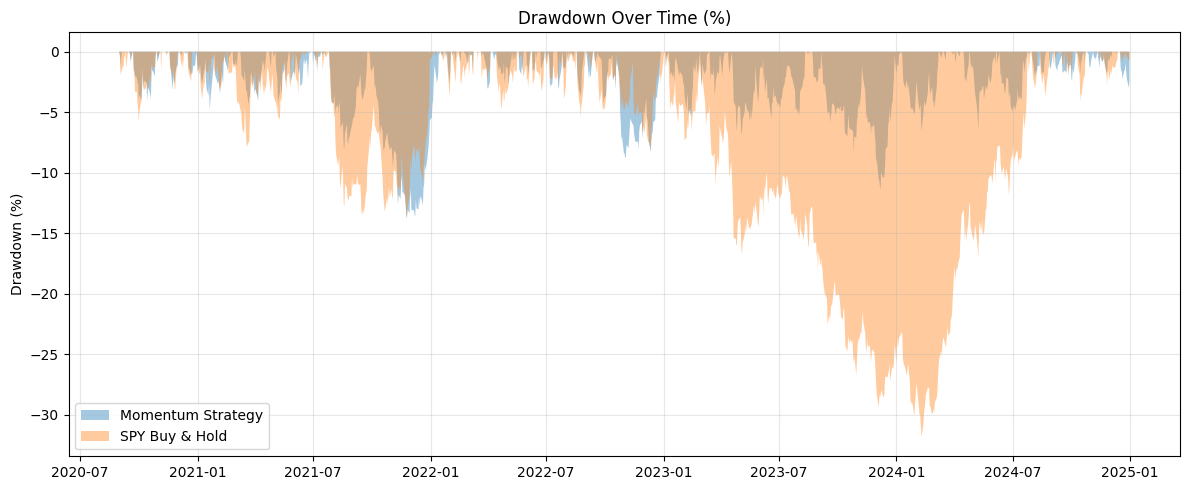

In [7]:
def drawdown_series(returns):
    cum = (1 + returns).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

strat_dd = drawdown_series(strategy_returns)
bench_dd = drawdown_series(benchmark_returns)

plt.figure(figsize=(12, 5))
plt.fill_between(strat_dd.index, strat_dd * 100, 0, alpha=0.4, label='Momentum Strategy')
plt.fill_between(bench_dd.index, bench_dd * 100, 0, alpha=0.4, label='SPY Buy & Hold')
plt.title('Drawdown Over Time (%)')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Inspect the rebalance log

This is the most important sanity check in any backtest: look at *what the strategy actually held* at each point in time, and confirm the picks make sense given the momentum scores.

In [8]:
log_df = pd.DataFrame(result['holdings_log'])
log_df[['rebalance_date', 'holdings', 'momentum_scores', 'turnover', 'transaction_cost_pct']].tail(12)

,rebalance_date,holdings,momentum_scores,turnover,transaction_cost_pct
40,2023-12-29,"[NVDA, KO, GOOGL]","{'NVDA': 0.0357, 'KO': 0.0162, 'GOOGL': 0.007}",0.0000,0.0000
41,2024-01-31,"[NVDA, AAPL, GOOGL]","{'NVDA': 0.2243, 'AAPL': 0.0806, 'GOOGL': 0.0209}",0.6670,0.0667
42,2024-02-29,"[NVDA, AAPL, GOOGL]","{'NVDA': 0.1568, 'AAPL': 0.0196, 'GOOGL': -0.0...",0.0000,0.0000
43,2024-03-29,"[AAPL, GOOGL, MSFT]","{'AAPL': 0.084, 'GOOGL': 0.0197, 'MSFT': -0.0209}",0.6670,0.0667
44,2024-04-30,"[AAPL, NVDA, GOOGL]","{'AAPL': 0.2031, 'NVDA': 0.1772, 'GOOGL': 0.0954}",0.6670,0.0667
45,2024-05-31,"[AAPL, NVDA, GOOGL]","{'AAPL': 0.2648, 'NVDA': 0.2175, 'GOOGL': 0.1969}",0.0000,0.0000
46,2024-06-28,"[GOOGL, AAPL, XOM]","{'GOOGL': 0.3016, 'AAPL': 0.284, 'XOM': 0.1897}",0.6670,0.0667
47,2024-07-31,"[GOOGL, AAPL, AMZN]","{'GOOGL': 0.3509, 'AAPL': 0.232, 'AMZN': 0.2107}",0.6670,0.0667
48,2024-08-30,"[GOOGL, AMZN, XOM]","{'GOOGL': 0.4919, 'AMZN': 0.384, 'XOM': 0.3714}",0.6670,0.0667
49,2024-09-30,"[AMZN, GOOGL, XOM]","{'AMZN': 0.5144, 'GOOGL': 0.4192, 'XOM': 0.3929}",0.0000,0.0000


## 8. Sensitivity check: does this hold up across parameter choices?

A single backtest result can be luck. Testing a small grid of lookback windows and top-K values shows whether the edge is robust or fragile — fragile results (great at 6 months, terrible at 5 or 7) are a classic sign of overfitting.

In [9]:
sensitivity_results = []

for lookback in [3, 6, 9, 12]:
    for k in [2, 3, 4]:
        res = run_backtest(stock_prices, lookback_months=lookback, top_k=k, transaction_cost_bps=10.0)
        rets = res['daily_returns']
        if len(rets) < 50:
            continue
        m = summary_table(rets)
        sensitivity_results.append({
            'lookback_months': lookback,
            'top_k': k,
            'CAGR': m['CAGR'],
            'Sharpe': m['Sharpe Ratio'],
            'Max Drawdown': m['Max Drawdown'],
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.pivot(index='lookback_months', columns='top_k', values='Sharpe').round(2)

top_k,2,3,4
lookback_months,,,
3,1.5800,1.7300,1.9100
6,1.5100,1.8500,1.9900
9,1.3500,1.5500,1.6600
12,1.7700,1.6200,1.6800


**Reading this table:** if Sharpe ratios are reasonably consistent across nearby parameter combinations, that's a sign the strategy's edge (if any) is structural rather than a curve-fit to one specific setting. Sharp cliffs between adjacent cells are a red flag.

## 9. Conclusion

See `output/REPORT.md` for the full written summary, or rerun `python src/run_analysis.py` from the command line to regenerate all charts and the report after changing data or parameters.

**Honest caveats (read before drawing conclusions):**
- Universe of 8 stocks is small and was not selected systematically (survivorship/selection bias risk).
- Transaction cost model (flat bps) is a simplification of real-world slippage.
- Placeholder data is calibrated to realistic statistics but is not real market history — rerun with `fetch_data.py` output before treating results as evidence.